In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
dataset_path = "data/creditcard.csv"

df = pd.read_csv(dataset_path)
print(df.head())
print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
le_target = LabelEncoder()

target_col = 'Class'

X = df.drop(columns=['Class'])
y = df['Class']

print(X.info())
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [5]:
print(df['Class'].value_counts().sort_index())
print(f"Всего записей: {len(df)}")
print()

print("Классы в train")
unique, counts = np.unique(y_train, return_counts=True)
train_dist = dict(zip(unique, counts))
for code, count in sorted(train_dist.items()):
    print(f"{code} : {count}")
print(f"Всего в train: {len(y_train)}")
print()

# Тестовая выборка  
print("Классы в test")
unique, counts = np.unique(y_test, return_counts=True)
test_dist = dict(zip(unique, counts))
for code, count in sorted(test_dist.items()):
    print(f"{code} : {count}")
print(f"Всего в test: {len(y_test)}")
print()

Class
0    284315
1       492
Name: count, dtype: int64
Всего записей: 284807

Классы в train
0 : 227451
1 : 394
Всего в train: 227845

Классы в test
0 : 56864
1 : 98
Всего в test: 56962



In [6]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200,
                                          max_depth=6,
                                          min_samples_split=10,
                                          min_samples_leaf=5,
                                          class_weight='balanced',
                                          random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_train = rf_pipeline.predict(X_train)
y_pred_test = rf_pipeline.predict(X_test)

Accuracy на train: 0.998
Accuracy на test:  0.998

Метрики по классам
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.45      0.87      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962



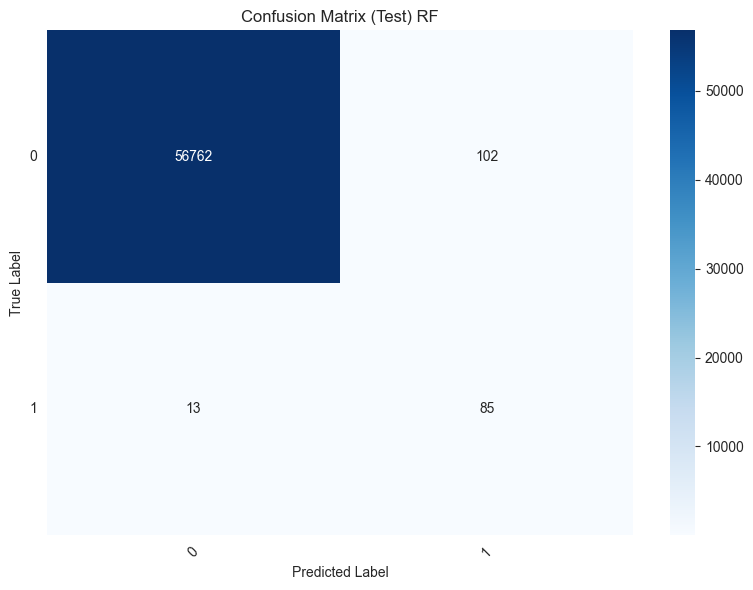

In [7]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test):.3f}")
print()

print("Метрики по классам")
target_names = ["0", "1"]
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) RF')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_train_gb = gb_pipeline.predict(X_train)
y_pred_test_gb = gb_pipeline.predict(X_test)


In [ ]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_gb):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_gb):.3f}")
print()

print("Метрики по классам")
target_names = ["0", "1"]
print(classification_report(y_test, y_pred_test_gb, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) GBDT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_train_svm = svm_pipeline.predict(X_train)
y_pred_test_svm = svm_pipeline.predict(X_test)


In [ ]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_svm):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_svm):.3f}")
print()

print("Метрики по классам")
target_names = ["0", "1"]
print(classification_report(y_test, y_pred_test_svm, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
ensemble_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=[
            ('gb', GradientBoostingClassifier(
                n_estimators=200, max_depth=6, min_samples_split=10,
                min_samples_leaf=5, random_state=42
            )),
            ('svm', SVC(C=1.0, kernel='rbf', gamma='scale', class_weight='balanced',
                        probability=True, random_state=42))
        ],
        voting='soft'  # soft для вероятностей, требует probability=True в SVC
    ))
])

ensemble_pipeline.fit(X_train, y_train)
y_pred_train_ensemble = ensemble_pipeline.predict(X_train)
y_pred_test_ensemble = ensemble_pipeline.predict(X_test)


In [ ]:
print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train_ensemble):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test_ensemble):.3f}")
print()

print("Метрики по классам")
target_names = ["0", "1"]
print(classification_report(y_test, y_pred_test_ensemble, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test) XGDT + SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()